In [1]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl
%config InlineBackend.figure_format='retina'

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch

import sys
sys.path.append('../factorised-MA-AIF/')

from games import *
# from agent import Agent
from network_agent import NetworkAgent
import utils.simulation

In [95]:
available_games = {
    'Ch': chicken_2player, 
    'PD': prisoners_dilemma_2player, 
    'SH': stag_hunt_2player, 
    'Ha': harmony_2player
}

def get_game_name(this_game, available_games):
    for key, game in available_games.items():
        if torch.equal(this_game, game):
            return key
    return None

Simulation: n=100 agents playing 525 games
(0, 3) -- SH
(0, 11) -- PD
(0, 25) -- Ha
(0, 27) -- Ha
(0, 43) -- Ch
(0, 46) -- Ch
(0, 49) -- SH
(0, 61) -- Ch
(0, 69) -- Ch
(0, 70) -- Ch
(0, 72) -- Ch
(0, 83) -- PD
(0, 97) -- SH
(1, 9) -- Ha
(1, 14) -- PD
(1, 22) -- Ha
(1, 33) -- Ha
(1, 54) -- Ch
(1, 65) -- SH
(1, 71) -- PD
(1, 79) -- PD
(2, 3) -- PD
(2, 18) -- SH
(2, 35) -- SH
(2, 42) -- SH
(2, 45) -- Ch
(2, 46) -- SH
(2, 48) -- PD
(2, 79) -- PD
(2, 88) -- PD
(2, 98) -- Ch
(3, 14) -- Ha
(3, 28) -- SH
(3, 31) -- Ha
(3, 55) -- PD
(3, 68) -- Ch
(3, 70) -- SH
(3, 85) -- Ha
(3, 88) -- Ch
(3, 89) -- PD
(3, 97) -- Ch
(4, 11) -- Ch
(4, 13) -- PD
(4, 16) -- PD
(4, 18) -- Ha
(4, 19) -- PD
(4, 21) -- SH
(4, 31) -- SH
(4, 36) -- SH
(4, 40) -- Ha
(4, 49) -- Ha
(4, 63) -- Ch
(4, 75) -- Ch
(4, 81) -- Ch
(4, 82) -- Ha
(4, 88) -- Ch
(4, 91) -- Ch
(5, 9) -- Ha
(5, 17) -- PD
(5, 21) -- PD
(5, 35) -- PD
(5, 40) -- Ha
(5, 45) -- SH
(5, 85) -- Ch
(5, 95) -- PD
(6, 10) -- Ha
(6, 11) -- Ha
(6, 14) -- Ha
(6, 31) -

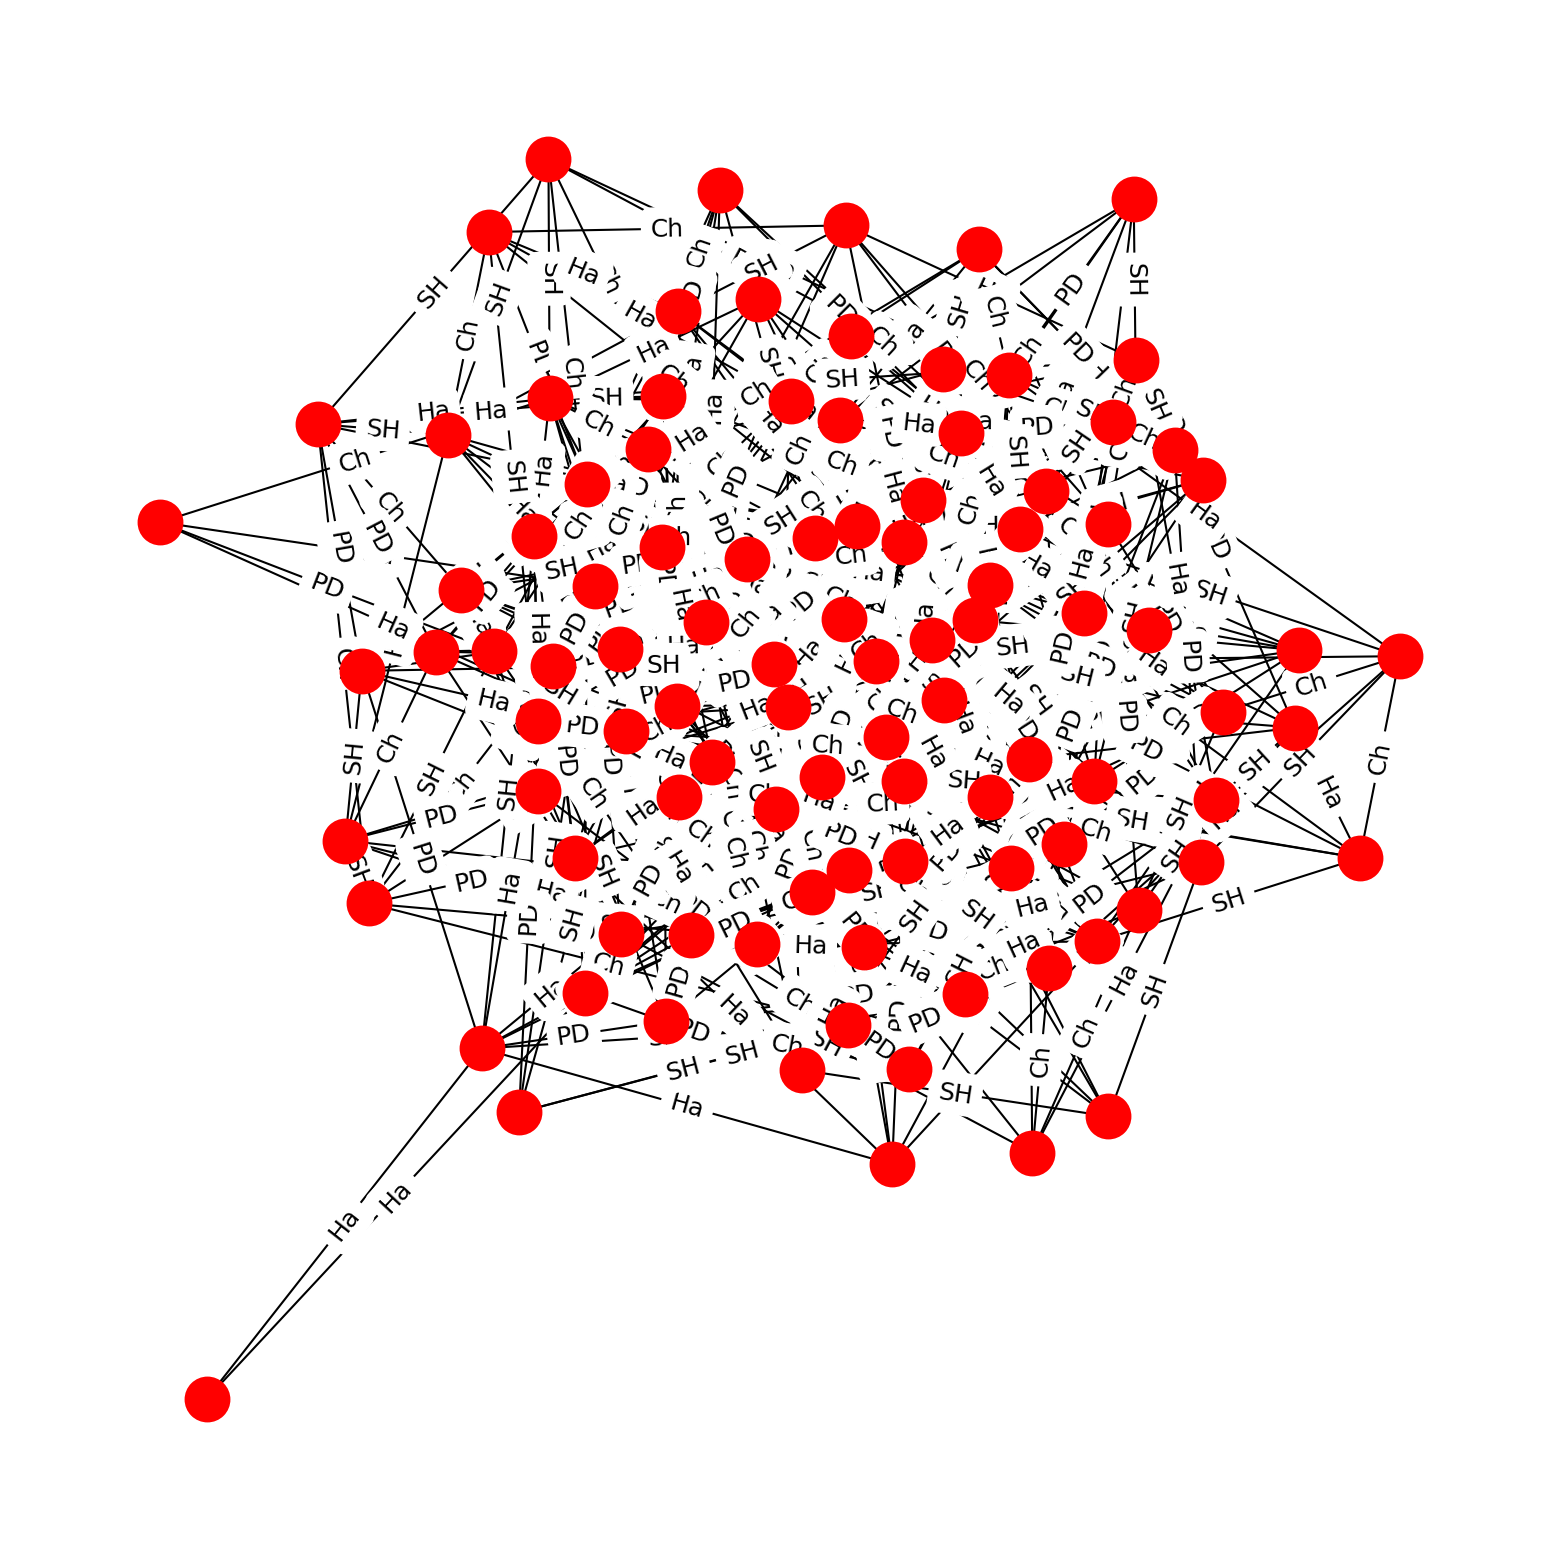

In [96]:
# Predefined constants
n = 100  # Number of nodes
p = 0.1  # Probability of edge creation

# Generate an Erdős-Rényi network
G = nx.erdos_renyi_graph(n, p)

# Assign a random game to each edge in the graph
for edge in G.edges:
    G.edges[edge]['game'] = list(available_games.values())[np.random.randint(len(available_games))]

# List the edges and their corresponding games
print(f"Simulation: n={G.number_of_nodes()} agents playing {G.number_of_edges()} games")
for edge in G.edges(data=True):
    game = edge[2]['game']
    game_name = get_game_name(game, available_games)
    print(f"{edge[:2]} -- {game_name}")

# Plot the network
plt.figure(figsize=(5, 5), dpi=150)
pos = nx.spring_layout(G)
nx.draw(
    G, 
    pos, 
    with_labels=False, 
    node_size=100, 
    node_color='red', 
    edge_color='black', 
    width=0.5
)
edge_labels = {(edge[0], edge[1]): get_game_name(edge[2]['game'], available_games) for edge in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
plt.show()

In [97]:
T = 50
num_players = len(G.nodes)  # Number of players (nodes in the graph)

agent_kwargs = [                                                                # <--- Define agent configurations here
    dict(
        beta_1=300.,
        dynamic_precision=True,
        decay=0.9,
        A_learning=False,
        learn_every_t_steps=30,
        learning_offset=8,
    )
] * num_players

# Initialisation ---------------------------------------------------------------
agents = []
for node in G.nodes:
    adjacent_games = [G.edges[edge]['game'] for edge in G.edges(node)]
    agents.append(
        NetworkAgent(
            id=node, 
            game_matrices=adjacent_games, 
            **agent_kwargs[node]
        )
    )

# Instantiate the simulator object
ig = utils.simulation.IteratedNetworkGame(agents=agents, network=G, seed=None)

# Simulation -------------------------------------------------------------------
variables_history = ig.run(T)

INFO:root:Simulation started with seed 42
INFO:root:t=0/50
INFO:root:t=0/50
INFO:root:t=50/50 Simulation complete


Text(0, 0.5, 'q_u')

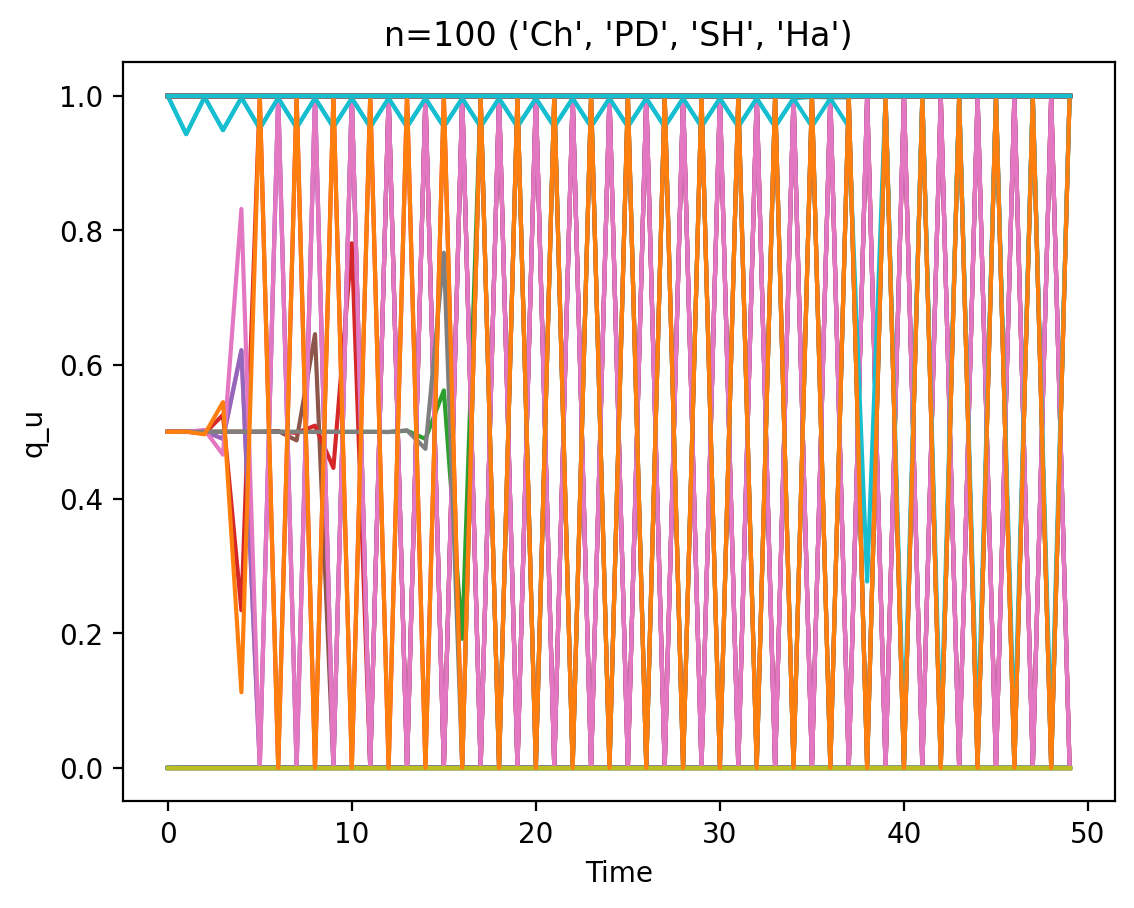

In [98]:
MARGIN = 0.05
q_u_history = np.array(variables_history['q_u'])
for i in range(num_players):
    plt.plot(q_u_history[:, i, 0], label='Agent 0')  # indices: time, agent, action
plt.ylim(0-MARGIN, 1+MARGIN)
plt.title(f'n={len(G.nodes)} {tuple(available_games.keys())}')
plt.xlabel('Time')
plt.ylabel('q_u')

Simulation: n=30 agents playing 59 games


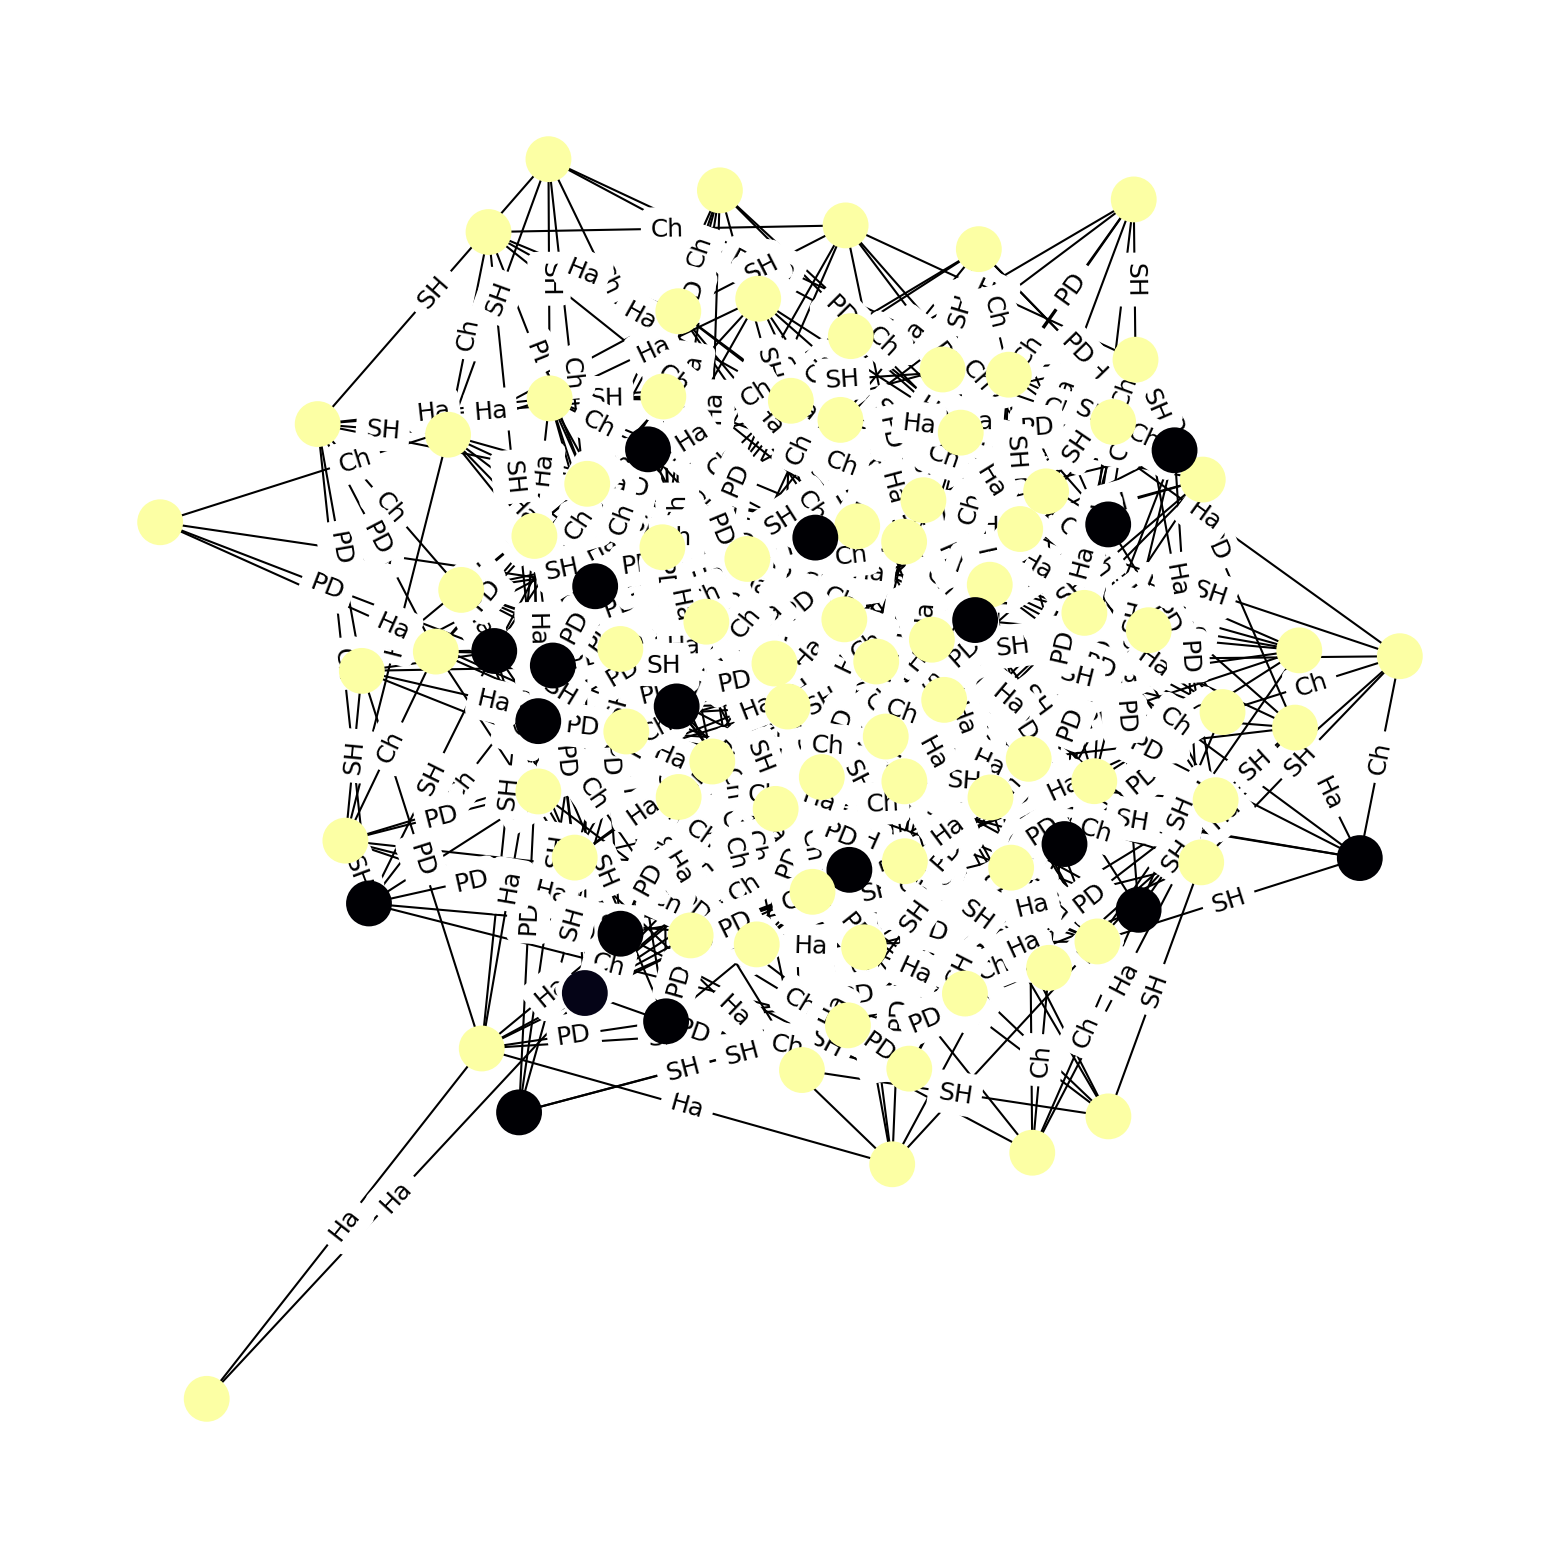

In [99]:
node_intensity = q_u_history[-2, :, 0]  # Extract node intensities
plt.figure(figsize=(5, 5), dpi=150)
nx.draw(
    G, 
    pos, 
    with_labels=False, 
    node_size=100, 
    node_color=node_intensity, 
    vmin=0, 
    vmax=1, 
    edge_color='black', 
    cmap=plt.cm.inferno,
    width=0.5
)
edge_labels = {(edge[0], edge[1]): get_game_name(edge[2]['game'], available_games) for edge in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
plt.show()